In [ ]:
# Lending Club Machine Learning Model 구현

# 1. 기본적으로 우리에게 주어진 feature(독립변수)는 150개예요!
#    당연히 종속변수(loan_status)에 영향을 많이 미치는 feature와 그렇지 않은 feature가 있어요!
#    하지만 이 부분은 일단 배제할꺼예요!
#    사용하는 feature는 문제에서 제시한 주요한 feature로 명시된 9개만 사용!
#     loan_amnt : 대출 금액 (연속적인 실수)
#     term :  상환 기간 (36개월, 60개월)
#     int_rate : 이자율 (연속적인 실수)
#     grade : 신용 등급 (A~G)
#     emp_length : 근속 기간
#     home_ownership: 주거 형태 (OWN, RENT 등) 
#     annual_inc : 연간 수입 (연속적인 실수)
#     purpose : 대출 목적
#     dti : 부채 대비 소득 비율 (Debt to Income) (연속적인 실수)
#     loan_status : 대출 상태 (타겟 변수)
#  컬럼을 선정한 특별한 이유는 없어요.. 그냥 이 컬럼으로 일단 해 볼꺼예요!

In [ ]:
# 먼저 생각해야 할 것 중 하나는 Tree기반 모델을 사용할것인지 아니면
# 거리기반(선형기반)모델을 사용할 것인지를 결정하는 거예요!
# Tree기반(Decision Tree, RandomForest, XGBoost, LightGBM) 모델은
# 입력값을 기준으로 크다/작다를 split해서 학습을 진행. 그래서
# bin번호(binning처리할때의 숫자) 자체만으로도 잘 학습해요!

# 선형 모델(거리기반모델)은 입력값을 연속적인 숫자로 인식해요. 그래서
# bin번호(binning처리할때의 숫자)를 이용하면 이 숫자간의 연속적인 차이를 인식하려고
# 해요. 따라서 이런 경우에는 one-hot encoding처리를 하면 되요!
# 하지만 one-hot은 feature가 늘어난다는 단점이 있어요!. 적당히 늘어나면 큰 문제 없어요!
# 하지만 bin번호가 너무 많아지면 feature의 수가 너무 많이 증가하기 때문에 이런 경우에는
# embedding을 사용해야 해요!

In [ ]:
# xgboost와 lightgbm을 이용할꺼예요!
!pip install xgboost
!pip install lightgbm

In [2]:
# 필요한 module import
%reset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler  # 일반적 - 이상치에 아주 민감(최대,최소를 이용)
from sklearn.preprocessing import StandardScaler # 이상치에 덜 민감.(평균,표준편차 이용)
from sklearn.preprocessing import RobustScaler # 이상치에 아주 강건 (IQR value를 이용)
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [3]:
# Raw Data Loading
# 많은 양의 데이터를 pandas를 이용해서 읽어와서 DataFrame을 생성해야 하기 때문에
# low_memory=False 옵션을 이용
df = pd.read_csv('./accepted_2007_to_2018Q4.csv', low_memory=False)

In [ ]:
# 데이터 확인(몇개의 행이 있고 컬럼은 몇개인지 확인)
df.shape  # (2260701, 151)

In [ ]:
# 필요한 컬럼만 추출
df_1 = df[['loan_amnt','term','int_rate','grade','emp_length','home_ownership',
          'annual_inc','purpose','dti','loan_status']]
df_1.shape # (2260701, 10)

In [6]:
# Feature Engineering은 제외하고 데이터 전처리로 들어가 보아요!
# 데이터 전처리

# 1. 결측치 처리 (삭제)
df_2 = df_1.dropna(how='any', inplace=False)
df_2.shape  # (2113644, 10)  # 147,057개의 데이터가 삭제!
# 데이터가 충분히 많기 때문에 이런 경우는 삭제가 정답이예요!

(2113644, 10)

In [ ]:
df_2.info()

In [ ]:
# np.unique(df_2['term'], return_counts=True)
df_2['term_binary'] = np.where(df_2['term'] == ' 36 months', 0, 1)
df_3 = df_2.drop('term', axis=1, inplace=False)
df_3.head()

In [ ]:
# grade 역시 숫자로 변경해야 해요!
# A~G가지 범주형 데이터로 문자형태로 저장되어 있는데 이걸 숫자로 변경할꺼예요!
# 0~6으로 숫자로 변환할 수 있어요!(label encoding이라고 해요!)
# 그런데 추후에 이 값을 정규화 시키면 안되요!(범주이기 때문에 값의 크기를 가지면 곤란해요!!)
# 따라서 이 같은 경우 one-hot encoding으로 변경시키면 조금 더 처리하기 좋을 듯 싶어요!
# np.unique(df_3['grade'], return_counts=True)
df_3_grade_encoded = pd.get_dummies(df_3['grade'], prefix='grade').astype(int)
df_4 = pd.concat([df_3, df_3_grade_encoded], axis=1)
df_5 = df_4.drop('grade', axis=1, inplace=False)

In [ ]:
df_5_home_ownership_encoded = pd.get_dummies(df_5['home_ownership'], prefix='home_ownership').astype(int)
df_6 = pd.concat([df_5, df_5_home_ownership_encoded], axis=1)
df_7 = df_6.drop('home_ownership', axis=1, inplace=False)

In [23]:
df_7_purpose_encoded = pd.get_dummies(df_7['purpose'], prefix='purpose').astype(int)
df_8 = pd.concat([df_7, df_7_purpose_encoded], axis=1)
df_9 = df_8.drop('purpose', axis=1, inplace=False)

In [ ]:
# np.unique(df_9['emp_length'], return_counts=True)

In [ ]:
# 근속연수(emp_length)는 단순히 one-hot처리를 하는것 보다는
# Binning처리를 먼저하고 그 후에 one-hot으로 처리하는게 좋을 듯 싶어요!
def convert_year(x):
    if x == '< 1 year':
        return 0
    elif x == '10+ years':
        return 10
    else:
        return int(x.split()[0])
# 함수를 적용해보아요!
df_9['emp_length_year'] = df_9['emp_length'].apply(convert_year)

# 숫자로 변환한 다음 Binning처리를 하면 될 듯 해요!
# 그러면 어떤 범위로 Binning처리를 하는게 좋을까요???
# 0 ~ 10까지 숫자가 있는데 어떻게 Bin을 설정하는게 좋을까요??
# 3등급으로 나눌수도 있고 2등급으로 나눌수도 있고 4등급으로 나눌수도 있어요!
# Binning은 어떻게 하는게 좋은가요?? 라는것에 대한 방법이 있어요!
# 일단 이 feature는 알고리즘을 사용하지 말고 그냥 기준을 잡아서 나눌꺼예요!

# Binning 처리
conditions = [(
    df_9['emp_length_year'] <= 1
),(
    (df_9['emp_length_year'] >= 2) & (df_9['emp_length_year'] <= 7)
),(
    df_9['emp_length_year'] >= 8
)]
choices = ['short', 'medium', 'long']

df_9['emp_length_year_binned'] = np.select(conditions,choices)

df_9_emp_length_year_binned_encoded = pd.get_dummies(df_9['emp_length_year_binned'], prefix='emp_length_year_binned').astype(int)
df_10 = pd.concat([df_9, df_9_emp_length_year_binned_encoded], axis=1)
df_11 = df_10.drop('emp_length_year_binned', axis=1, inplace=False)
df_12 = df_11.drop(['emp_length', 'emp_length_year'], axis=1, inplace=False)
df_12

# 연속적인 실수값은 일단 아직 처리 전이고
# 종속변수 아직 처리 전이고
# 범주형 데이터는 모두 one-hot encoding으로 변경해서 처리했어요!

In [ ]:
# 종속변수(target)도 처리해야 해요!
# np.unique(df_12['loan_status'], return_counts=True)
df_12['loan_status_binary'] = np.where(df_12['loan_status'].isin(['Current','Fully Paid']), 0, 1)
df_13 = df_12.drop('loan_status', axis=1, inplace=False)
df_13

In [31]:
# 종속변수의 데이터 불균형 확인
np.unique(df_13['loan_status_binary'], return_counts=True)
# 데이터의 불균형이 있어요. 그냥 학습을 시키면 정상적인 학습이 이루어지지 않아요!
# SMOTE 이용해서 데이터의 불균형을 해결한 다음 학습을 진행해야 해요!

(array([0, 1]), array([1832108,  281536], dtype=int64))

In [32]:
df_13
# 연속적인 숫자형 데이터가 4 feature
# 나머지는 one-hot encoding이예요!
# 어떻게 하는게 좋을까요? 일반적으로 연속값을 범주형으로 변환할때 더 성능이
# 좋아지는 경우가 많아요!(특히 Tree계열의 알고리즘을 사용할때)

# 그러면 어떤 경우에 범주형으로 변환하면 더 좋을까요?
# 1. 값이 구간별 의미를 가지는 경우 (나이)
# 2. 이상치가 많은 경우에는 범주형으로 변경하면 좋아요!


,loan_amnt,int_rate,annual_inc,dti,term_binary,grade_A,grade_B,grade_C,grade_D,grade_E,...,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,emp_length_year_binned_long,emp_length_year_binned_medium,emp_length_year_binned_short,loan_status_binary
0,3600.0,13.99,55000.0,5.91,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
1,24700.0,11.99,65000.0,16.06,0,0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,0
2,20000.0,10.78,63000.0,10.78,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,35000.0,14.85,110000.0,17.06,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
4,10400.0,22.45,104433.0,25.37,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260694,24000.0,12.79,95000.0,19.61,1,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2260695,24000.0,10.49,108000.0,34.94,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2260696,40000.0,10.49,227000.0,12.75,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2260697,24000.0,14.49,110000.0,18.30,1,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,1


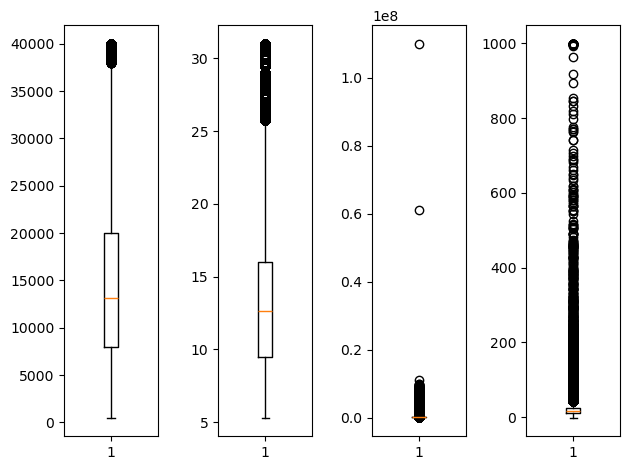

In [34]:
# 이상치를 한번 확인해 보아요!
fig = plt.figure()
ax1 = fig.add_subplot(1,4,1)
ax2 = fig.add_subplot(1,4,2)
ax3 = fig.add_subplot(1,4,3)
ax4 = fig.add_subplot(1,4,4)

ax1.boxplot(df_13['loan_amnt'])
ax2.boxplot(df_13['int_rate'])
ax3.boxplot(df_13['annual_inc'])
ax4.boxplot(df_13['dti'])
plt.tight_layout()
plt.show()

In [37]:
# df_13.describe()  # 각 컬럼의 기본 통계치를 알려줘요!
# 기본적으로는 지수형태로 출력이 되요!
# pandas의 옵션을 살짝 변경하면 지수형태가 아닌 일반 숫자 형태로 출력할 수 있어요!
pd.set_option('display.float_format', '{:.2f}'.format)
df_13.describe().iloc[:,0:4]

,loan_amnt,int_rate,annual_inc,dti
count,2113644.00,2113644.00,2113644.00,2113644.00
mean,15250.22,13.09,79966.91,18.58
std,9221.12,4.83,115191.83,11.81
min,500.00,5.31,0.00,-1.00
25%,8000.00,9.49,48000.00,11.86
50%,13100.00,12.62,67000.00,17.73
75%,20000.00,15.99,95000.00,24.32
max,40000.00,30.99,110000000.00,999.00


In [ ]:
# 이상치를 확인하기 위해 boxplot으로 확인도 해보고
# 기본통계를 이용해서 확인도 해 보았어요!

# 이상치를 발견하면
# 진짜 이상치인지 확인
#     진짜 이상한 값이면 -> 삭제하거나 대체
#     자연스러운 이상한 값 -> 그냥 살려야 해요!

# 진짜 오류데이터이면 일반적으로 삭제
# 이상치가 너무 크지만 의미가 있는 경우 -> clipping
# 이상치가 너무 많은 경우 -> 변환(로그변환)    log10 => 1, log100 -> 2, log1000 -> 3

In [ ]:
# dti같은 경우 부채비율이기 때문에 무조건 양수이어야 해요!
# 그리고 부채비율이 100이 넘는것들은 제외!
df_14 = df_13[(df_13['dti'] >= 0) & (df_13['dti'] < 100)]
df_14.shape  # (2112224, 36)
df_14.describe().iloc[:,0:4]


In [ ]:
# annual_inc은 상위 99%까지의 데이터로 clipping
tmp = df_14['annual_inc'].quantile(0.99)
df_14['annual_inc'] = df_14['annual_inc'].clip(upper=tmp)
df_14.describe().iloc[:,0:4]

In [ ]:
df_14['annual_inc_log'] = np.log1p(df_14['annual_inc'])
df_14['dti_log'] = np.log1p(df_14['dti'])
df_15 = df_14.drop(['annual_inc', 'dti'], axis=1, inplace=False)
df_15

In [44]:
# 데이터 전처리기 다 끝났어요!
# 데이터 분할
x_data = df_15.drop('loan_status_binary', axis=1, inplace=False).values
t_data = df_15['loan_status_binary'].values

# 우리 데이터는 기본적으로 불균형을 가지고 있어요!
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_data_resampled, t_data_resampled = smote.fit_resample(x_data, t_data)
# np.unique(t_data_resampled, return_counts=True)

(array([0, 1]), array([1830804, 1830804], dtype=int64))

In [46]:
# 정규화

scaler = MinMaxScaler()
scaler.fit(x_data_resampled)
x_data_norm = scaler.transform(x_data_resampled)

# 데이터 분할
x_data_train_norm, x_data_test_norm, t_data_train, t_data_test = \
train_test_split(x_data_norm,
                t_data_resampled,
                test_size=0.2,
                stratify=t_data_resampled)